In [29]:
# Import the libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import joblib
import json
import plotly.express as px

In [2]:
# Load the data
df = pd.read_csv('../data/credit_card_final.csv')

# Head
df.head()

,purchases_frequency,oneoff_share,cash_advance_ratio,oneoff_purchases_frequency
0,-0.951520,-0.951750,-0.751907,-0.739894
1,-1.372104,-0.951750,1.596484,-0.739894
2,-1.161813,1.427420,-0.751907,-0.480047
3,1.151393,1.196456,-0.751907,2.378288
4,1.151393,-0.951750,-0.751907,-0.739894


In [3]:
# Evaluate kmeans
def evaluate_kmeans(X, k_range, n_repeats = 5):
    results = []
    for k in k_range:
        inertias = []
        sil_scores = []
        db_scores = []
        for _ in range(n_repeats):
            km = KMeans(n_clusters = k, random_state = None, n_init = 10)
            labels = km.fit_predict(X)
            inertias.append(km.inertia_)
            if k > 1:
                sil_scores.append(silhouette_score(X, labels))
                db_scores.append(davies_bouldin_score(X, labels))
            
            avg_inertia = np.mean(inertias)
            avg_sil = np.mean(sil_scores) if k > 1 else 0
            avg_db = np.mean(db_scores) if k > 1 else np.inf

            results.append({
                'k': k,
                'inertia': avg_inertia,
                'silhouette': avg_sil,
                'davies_bouldin': avg_db
            })
    return pd.DataFrame(results)

In [4]:
# Start clustering with at least 2
X = df.values

k_range = range(2, 11)
kmeans_results = evaluate_kmeans(X, k_range, n_repeats = 5)
print(kmeans_results)

     k       inertia  silhouette  davies_bouldin
0    2  15385.049092    0.417840        0.928579
1    2  15385.060264    0.417808        0.928799
2    2  15385.056252    0.417819        0.928726
3    2  15385.054462    0.417824        0.928689
4    2  15385.056119    0.417827        0.928667
5    3   9263.710443    0.474900        0.890788
6    3   9263.710443    0.474900        0.890788
7    3   9263.710443    0.474900        0.890788
8    3   9263.710443    0.474900        0.890788
9    3   9263.711310    0.474903        0.890816
10   4   5597.847915    0.554212        0.732402
11   4   5597.847915    0.554212        0.732402
12   4   5597.846957    0.554212        0.732402
13   4   5597.847477    0.554212        0.732402
14   4   5597.846657    0.554206        0.732514
15   5   4565.041469    0.565828        0.712922
16   5   4565.042531    0.565833        0.713144
17   5   4565.042079    0.565850        0.713064
18   5   4565.041854    0.565859        0.713025
19   5   4565.042806

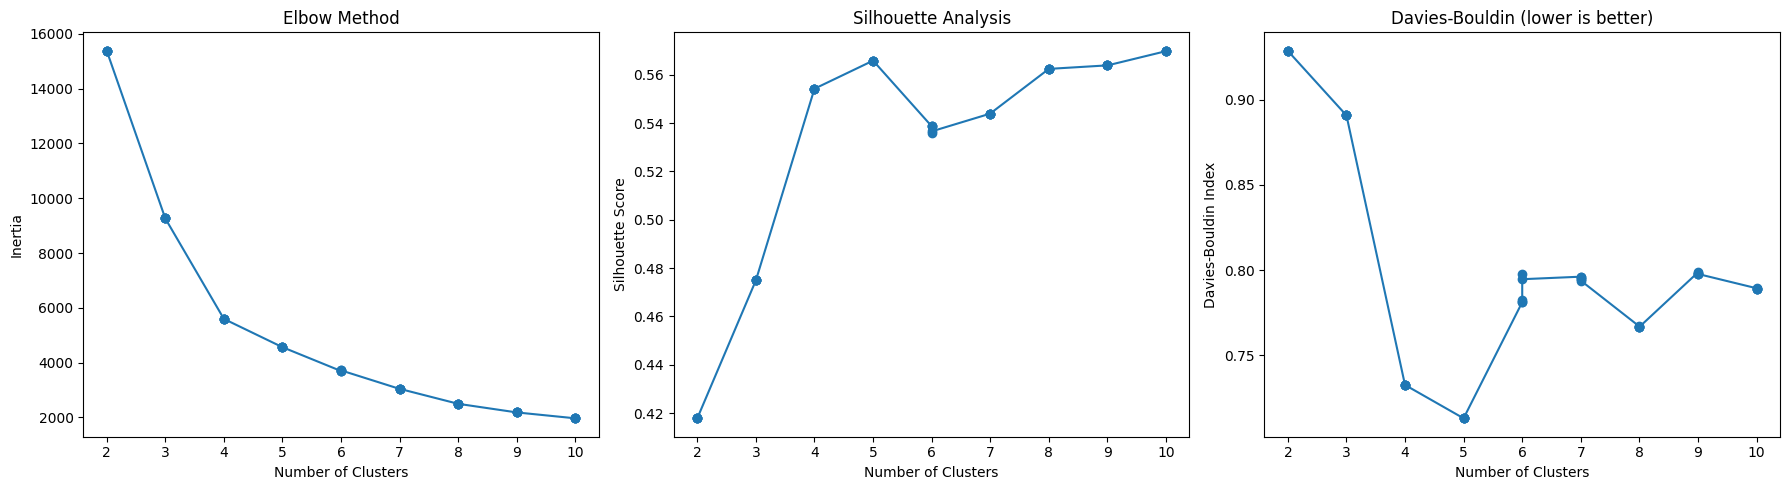

In [5]:
# Plot the metrics to pick the best
fig, axes = plt.subplots(1, 3, figsize = (18, 5))

axes[0].plot(kmeans_results['k'], kmeans_results['inertia'], marker = 'o')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(kmeans_results['k'], kmeans_results['silhouette'], marker = 'o')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')

axes[2].plot(kmeans_results['k'], kmeans_results['davies_bouldin'], marker = 'o')
axes[2].set_xlabel('Number of Clusters')
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].set_title('Davies-Bouldin (lower is better)')

plt.tight_layout()
plt.show()

Regarding above findings, 4 or 5 clusters look promising for our model, yet we are going to model with DBSCAN as well.

In [6]:
def evaluate_dbscan(X, eps_values, min_samples_values):
    results = []
    for eps in eps_values:
        for min_samp in min_samples_values:
            db = DBSCAN(eps = eps, min_samples = min_samp)
            labels = db.fit_predict(X)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)
            noise_ratio = n_noise / len(labels)

            if n_clusters > 1 and n_noise < len(labels):
                sil = silhouette_score(X, labels)
            else:
                sil = -1
            
            results.append({
                'eps': eps,
                'min_samples': min_samp,
                'n_clusters': n_clusters,
                'noise_ratio': noise_ratio,
                'silhouette': sil
            })
    
    return pd.DataFrame(results)

In [7]:
# Define search space 
eps_values = [0.3, 0.5, 0.7, 0.9, 1.1, 1.3]
min_samples_values = [3, 5, 7, 10]

dbscan_results = evaluate_dbscan(X, eps_values, min_samples_values)

# Print top 10 results
display(dbscan_results.sort_values('silhouette', ascending = False).head(10))

# Filter by reasonable noise
good_dbscan = dbscan_results[(dbscan_results['noise_ratio'] < 0.2) & (dbscan_results['n_clusters'] >= 2)]

display(good_dbscan.sort_values('silhouette', ascending = False))

,eps,min_samples,n_clusters,noise_ratio,silhouette
4,0.5,3,2,0.000799,-0.094307
3,0.3,10,4,0.095208,-0.199061
2,0.3,7,5,0.075399,-0.290965
1,0.3,5,16,0.059425,-0.481379
0,0.3,3,37,0.032428,-0.594580
5,0.5,5,1,0.002077,-1.000000
6,0.5,7,1,0.002875,-1.000000
7,0.5,10,1,0.005591,-1.000000
8,0.7,3,1,0.000000,-1.000000
9,0.7,5,1,0.000000,-1.000000


,eps,min_samples,n_clusters,noise_ratio,silhouette
4,0.5,3,2,0.000799,-0.094307
3,0.3,10,4,0.095208,-0.199061
2,0.3,7,5,0.075399,-0.290965
1,0.3,5,16,0.059425,-0.481379
0,0.3,3,37,0.032428,-0.594580


By the negative score of sil in DBSCAN model above, we are left with K-means to proceed.

In [8]:
# k = 5 was the best sil score in our kmeans model
best_k = 5
final_km = KMeans(n_clusters = best_k, random_state = 42, n_init = 10)
df['cluster'] = final_km.fit_predict(X)

In [9]:
# Cluster profile
profile = df.groupby('cluster').mean()
profile['size'] = df['cluster'].value_counts().sort_index()
print(profile.round(2))

         purchases_frequency  oneoff_share  cash_advance_ratio  \
cluster                                                          
0                      -0.57          1.15                1.10   
1                       0.56         -0.73               -0.57   
2                      -1.28         -0.95                1.57   
3                       0.96          0.83               -0.54   
4                      -0.63          1.23               -0.70   

         oneoff_purchases_frequency  size  
cluster                                    
0                             -0.09   543  
1                             -0.55  2211  
2                             -0.74  1283  
3                              1.71  1324  
4                             -0.05   899  


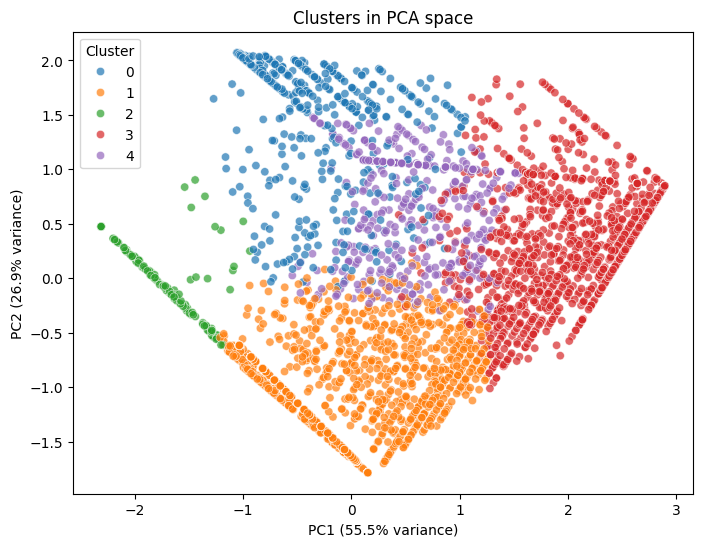

In [10]:
# PCA
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X)

# Create a DataFrame for plotting
df_pca = df[['cluster']].copy()
df_pca['PC1'] = X_pca[:, 0]
df_pca['PC2'] = X_pca[:, 1]

plt.figure(figsize = (8, 6))

sns.scatterplot(
    data = df_pca,
    x = 'PC1',
    y = 'PC2',
    hue = 'cluster',
    palette = 'tab10',
    alpha = 0.7
)

plt.title('Clusters in PCA space')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend(title = 'Cluster')
plt.show()

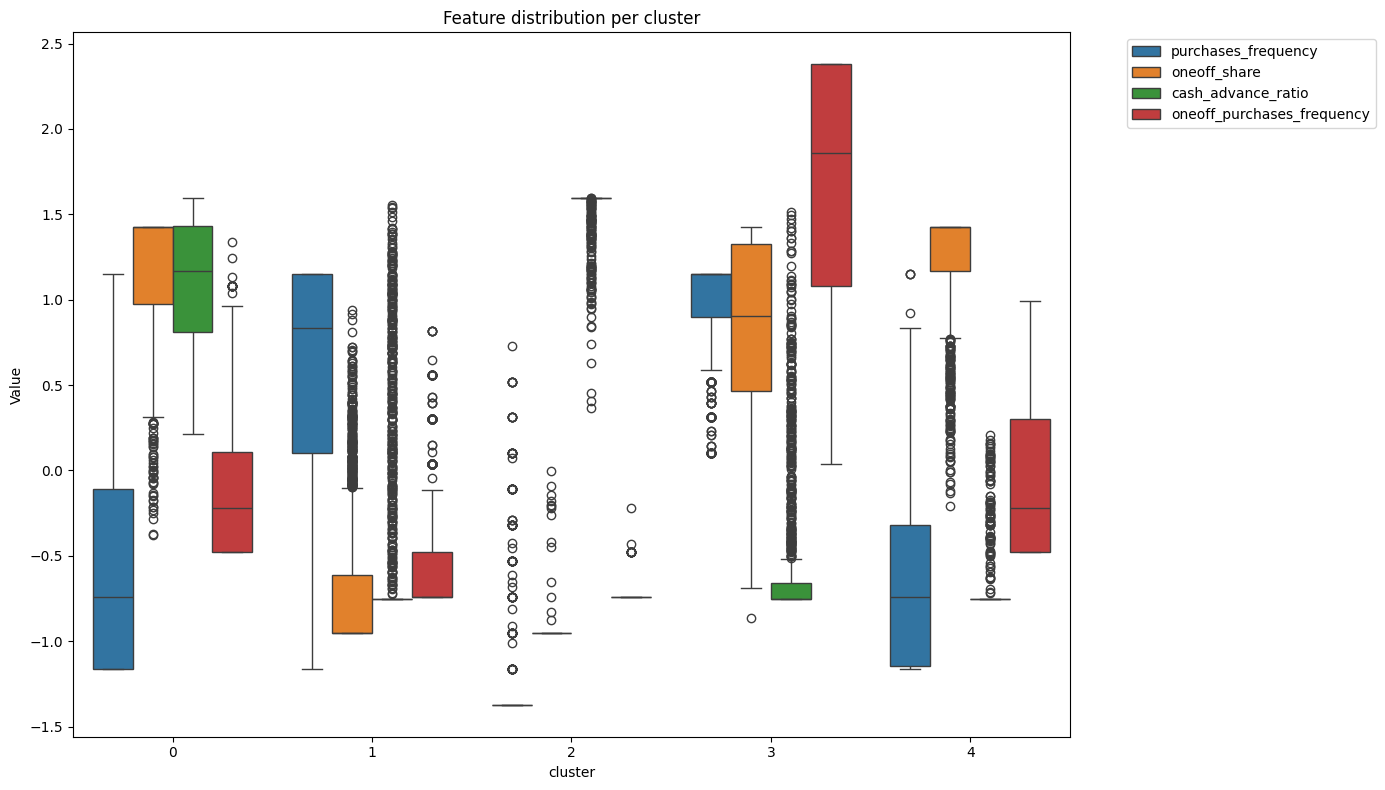

In [11]:
# Box plot for each 
features_cols = [col for col in df.columns if col != 'cluster']
df_melt = df.melt(id_vars = 'cluster', value_vars = features_cols,
                  var_name = 'Feature', value_name = 'Value')

plt.figure(figsize = (14, 8))

sns.boxplot(
    data = df_melt,
    x = 'cluster',
    y = 'Value',
    hue = 'Feature'
)

plt.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.title('Feature distribution per cluster')
plt.tight_layout()
plt.show()

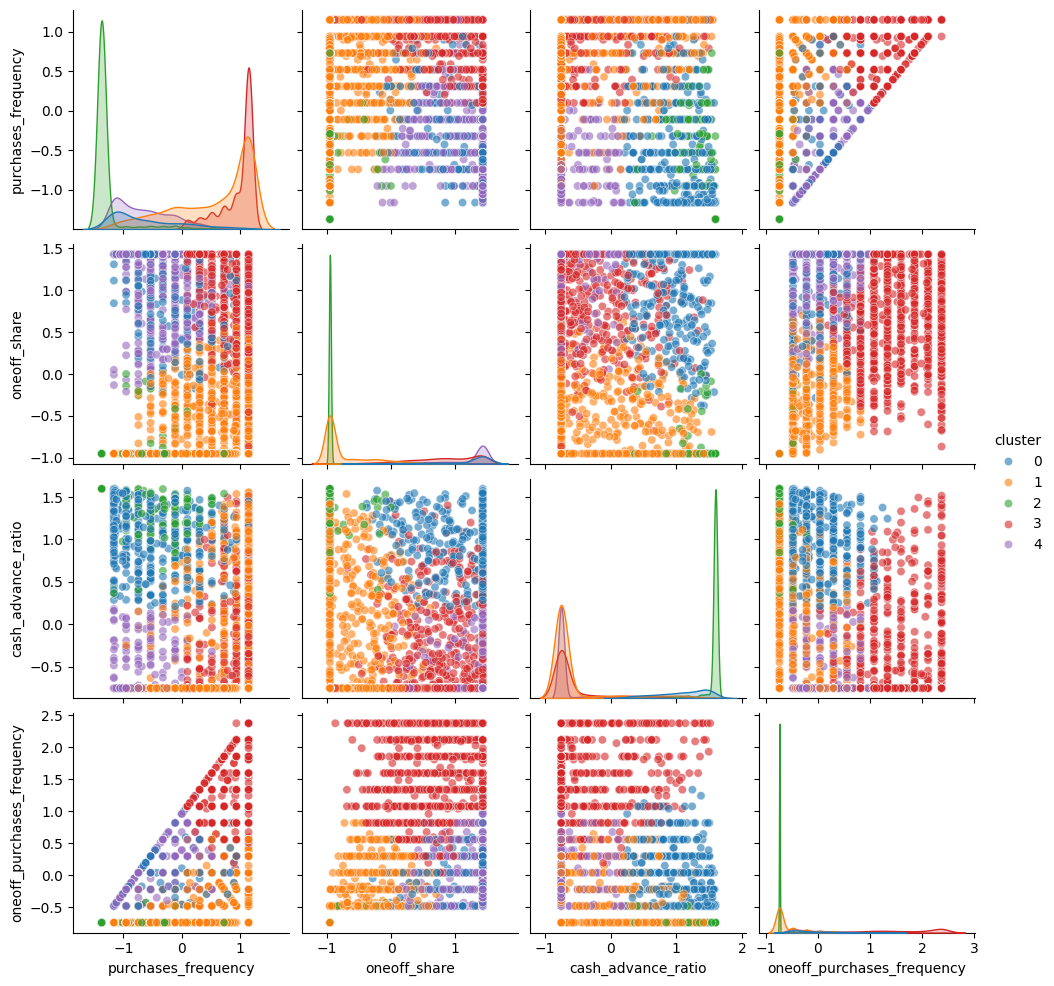

In [12]:
# Pairplot
sns.pairplot(
    df,
    vars = features_cols,
    hue = 'cluster',
    palette = 'tab10',
    diag_kind = 'kde',
    plot_kws = {'alpha': 0.6}
)

plt.show()

In [13]:
# 3D plot of our clusters
pca_3d = PCA(n_components = 3)
X_pca_3d = pca_3d.fit_transform(X)

# Create dataframe again
df_pca3 = df[['cluster']].copy()
df_pca3['PC1'] = X_pca_3d[:, 0]
df_pca3['PC2'] = X_pca_3d[:, 1]
df_pca3['PC3'] = X_pca_3d[:, 2]

expl_var = pca_3d.explained_variance_ratio_ * 100
print(f'Explained variance: PC1 = {expl_var[0]:.1f}%, PC2 = {expl_var[1]:.1f}%, PC3 = {expl_var[2]:.1f}%')

Explained variance: PC1 = 55.5%, PC2 = 26.9%, PC3 = 13.2%


In [16]:
fig = px.scatter_3d(
    df_pca3,
    x = 'PC1',
    y = 'PC2',
    z = 'PC3',
    color = 'cluster',
    color_discrete_sequence = px.colors.qualitative.T10,
    opacity = 0.7,
    title = 'K-Means clusters',
    labels = {'PC1': f'PC1 ({expl_var[0]:.1f}%)',
              'PC2': f'PC2 ({expl_var[1]:.1f}%)',
              'PC3': f'PC3 ({expl_var[2]:.1f}%)'}
)

fig.update_traces(marker = dict(size = 4))
fig.show()

Now we get to profiling our clusters.

In [17]:
# Mean
profile_mean = df.groupby('cluster')[features_cols].mean()

# Median
profile_median = df.groupby('cluster')[features_cols].median()

# Add size
profile_mean['size'] = df['cluster'].value_counts().sort_index()
profile_mean['pct'] = (profile_mean['size'] / len(df) * 100).round()

In [18]:
# Print
profile_mean.round(2)

,purchases_frequency,oneoff_share,cash_advance_ratio,oneoff_purchases_frequency,size,pct
cluster,,,,,,
0,-0.57,1.15,1.10,-0.09,543,9.0
1,0.56,-0.73,-0.57,-0.55,2211,35.0
2,-1.28,-0.95,1.57,-0.74,1283,20.0
3,0.96,0.83,-0.54,1.71,1324,21.0
4,-0.63,1.23,-0.70,-0.05,899,14.0


In [19]:
profile_median['size'] = profile_mean['size']
profile_median.round(2)

,purchases_frequency,oneoff_share,cash_advance_ratio,oneoff_purchases_frequency,size
cluster,,,,,
0,-0.74,1.43,1.17,-0.22,543
1,0.84,-0.95,-0.75,-0.74,2211
2,-1.37,-0.95,1.60,-0.74,1283
3,1.15,0.90,-0.75,1.86,1324
4,-0.74,1.43,-0.75,-0.22,899


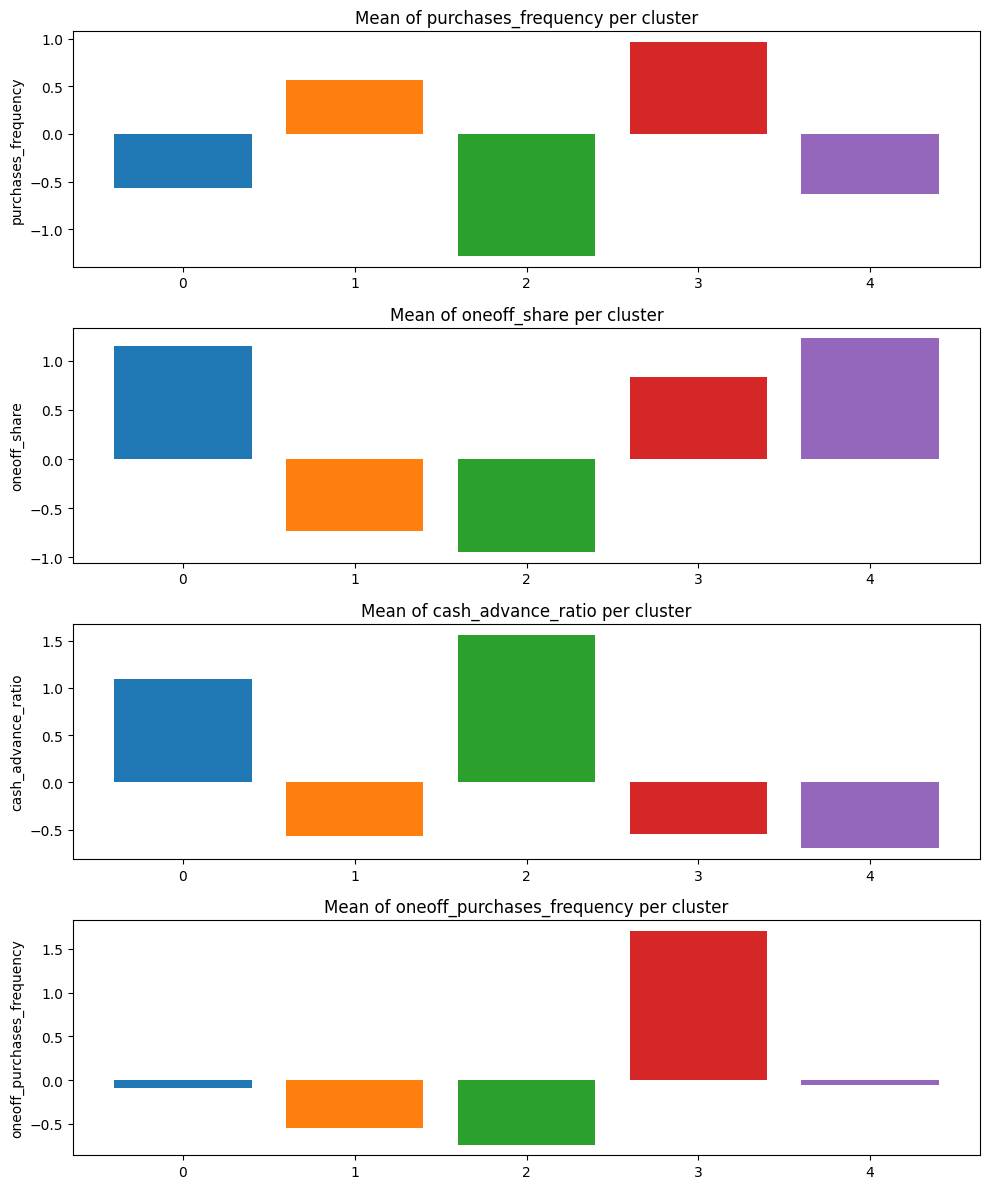

In [20]:
# Bar plot per feature
fig, axes = plt.subplots(len(features_cols), 1, figsize = (10, 3 * len(features_cols)))

for ax, feat in zip(axes, features_cols):
    means = profile_mean[feat]
    ax.bar(means.index.astype(str), means.values,
           color = plt.cm.tab10(np.arange(len(means))))
    ax.set_title(f'Mean of {feat} per cluster')
    ax.set_ylabel(feat)

plt.tight_layout()
plt.show()

In [21]:
# Automated description
def cluster_description(profile_mean_df):
    profile_no_size = profile_mean_df.drop(columns = ['size', 'pct'], errors = 'ignore')
    global_mean = profile_no_size.mean()

    for cluster in profile_no_size.index:
        diff = profile_no_size.loc[cluster] - global_mean
        high_feats = diff.nlargest(2).index.tolist()
        low_feats = diff.nsmallest(2).index.tolist()
        size = profile_mean_df.loc[cluster, 'size']
        pct = profile_mean_df.loc[cluster, 'pct']
        print(f'\nCluster {cluster} (size = {size}, pct = {pct}):')
        print(f'  >> Above average: {', '.join(high_feats)}')
        print(f'  << Below average: {', '.join(low_feats)}')

In [22]:
cluster_description(profile_mean)


Cluster 0 (size = 543, pct = 9.0):
  >> Above average: cash_advance_ratio, oneoff_share
  << Below average: purchases_frequency, oneoff_purchases_frequency

Cluster 1 (size = 2211, pct = 35.0):
  >> Above average: purchases_frequency, oneoff_purchases_frequency
  << Below average: oneoff_share, cash_advance_ratio

Cluster 2 (size = 1283, pct = 20.0):
  >> Above average: cash_advance_ratio, oneoff_purchases_frequency
  << Below average: oneoff_share, purchases_frequency

Cluster 3 (size = 1324, pct = 21.0):
  >> Above average: oneoff_purchases_frequency, purchases_frequency
  << Below average: cash_advance_ratio, oneoff_share

Cluster 4 (size = 899, pct = 14.0):
  >> Above average: oneoff_share, oneoff_purchases_frequency
  << Below average: cash_advance_ratio, purchases_frequency


Based on the information above we create a segment map and strategy for our customers.

In [25]:
SEGMENT_MAP = {
    0: {
        'segment_name': 'Cash-Advance Dependent',
        'description': 'Rarely buy, cash advances dominate, low credit limit, rarely pay full.',
        'strategy': 'Risk containment, financial education, offer personal loans instead of cash advances.'
    },
    1: {
        'segment_name': 'Everyday Super Users',
        'description': 'Frequent small purchasers, avoid cash advances, often pay full, high credit limit.',
        'strategy': 'Loyalty rewards, cashback, premium card upgrades, cross‑sell travel & insurance.'
    },
    2: {
        'segment_name': 'Mixed Spenders with Cash Need',
        'description': 'High cash advance AND many big purchases, moderate payment behaviour.',
        'strategy': 'Balance transfer offers, instalment plans, monitor for delinquency.'
    },
    3: {
        'segment_name': 'High-Volume Balanced Spenders',
        'description': 'Extremely active, both small and large purchases, very few cash advances.',
        'strategy': 'Premium cards, higher credit lines, concierge services, retention campaigns.'
    },
    4: {
        'segment_name': 'Big Ticket Spenders',
        'description': 'Infrequent but very large purchases, rarely use cash advances, high credit limit.',
        'strategy': 'Encourage everyday use with bonus points, instalment options for large items.'
    }
}

In [26]:
# Attach to the dataframe 
df['segment_name'] = df['cluster'].map(lambda x: SEGMENT_MAP[x]['segment_name'])
df['description'] = df['cluster'].map(lambda x: SEGMENT_MAP[x]['description'])
df['recommended_action'] = df['cluster'].map(lambda x: SEGMENT_MAP[x]['strategy'])

In [27]:
# Check the new dataset
df.head()

,purchases_frequency,oneoff_share,cash_advance_ratio,oneoff_purchases_frequency,cluster,segment_name,description,recommended_action
0,-0.951520,-0.951750,-0.751907,-0.739894,1,Everyday Super Users,"Frequent small purchasers, avoid cash advances...","Loyalty rewards, cashback, premium card upgrad..."
1,-1.372104,-0.951750,1.596484,-0.739894,2,Mixed Spenders with Cash Need,"High cash advance AND many big purchases, mode...","Balance transfer offers, instalment plans, mon..."
2,-1.161813,1.427420,-0.751907,-0.480047,4,Big Ticket Spenders,"Infrequent but very large purchases, rarely us...","Encourage everyday use with bonus points, inst..."
3,1.151393,1.196456,-0.751907,2.378288,3,High-Volume Balanced Spenders,"Extremely active, both small and large purchas...","Premium cards, higher credit lines, concierge ..."
4,1.151393,-0.951750,-0.751907,-0.739894,1,Everyday Super Users,"Frequent small purchasers, avoid cash advances...","Loyalty rewards, cashback, premium card upgrad..."


In [28]:
# Save the new dataset
df.to_csv('../data/app_data.csv', index = False)

In [30]:
# Save the model
joblib.dump(final_km, '../model/kmeans_model.pkl')

['../model/kmeans_model.pkl']

In [31]:
# Save the SEGMENT_MAP
with open('../model/segment_map.json', 'w') as f:
    json.dump(SEGMENT_MAP, f, indent = 2)